# 🤖 K-Nearest Neighbors (KNN) Algorithm

**K-Nearest Neighbors (KNN)** is a supervised machine learning algorithm used for both **classification** and **regression** tasks. It is considered a **lazy learning** and **non-parametric** algorithm.

* **Lazy Learning:** It does not have a dedicated training phase. Instead, it memorizes the entire dataset and performs the generalization during the prediction phase.
* **Non-parametric:** It makes no underlying assumptions about the distribution of the data.

---

## ⚙️ How the Algorithm Works

Given a new, unseen data point $x_{new}$, the KNN algorithm follows these steps to predict its label:

1. **Choose $K$**: Select the number of nearest neighbors ($K$).
2. **Calculate Distance**: Compute the distance between $x_{new}$ and every point $x_i$ in the training dataset.
3. **Find Nearest Neighbors**: Sort the distances in ascending order and select the top $K$ points closest to $x_{new}$.
4. **Make Prediction**:
   * **Classification:** Apply a majority vote. The most frequent class among the $K$ neighbors becomes the predicted class for $x_{new}$.
   * **Regression:** Calculate the mean (or median) of the target values of the $K$ neighbors.

---

## 📏 Distance Metrics

The choice of distance metric depends on the nature of the data. Let $p$ and $q$ be two data points with $n$ features.

### 1. Euclidean Distance (L2 Norm)
The standard straight-line distance, best used for continuous numerical data.
$$d(p, q) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}$$

### 2. Manhattan Distance (L1 Norm)
The sum of absolute differences across all dimensions. Useful for high-dimensional data or grid-like structures.
$$d(p, q) = \sum_{i=1}^{n} |q_i - p_i|$$

---

## 🧠 Choosing the Right $K$

The value of $K$ dictates the **bias-variance tradeoff** of the model:
* **Small $K$ (e.g., $K=1$):** Low bias, high variance. The model captures local noise and is prone to **overfitting**. Decision boundaries are jagged.
* **Large $K$:** High bias, low variance. The model is smoother and more generalized but may suffer from **underfitting** if $K$ is too large. 

> **💡 Best Practice:** Choose an **odd number** for $K$ to avoid tie-breakers in binary classification. The optimal $K$ is often found using **Cross-Validation**.

---

## ⏱️ Computational Complexity

* **Training Time:** $\mathcal{O}(1)$ — Just stores the data.
* **Prediction Time:** $\mathcal{O}(N \times D)$ — Where $N$ is the number of samples and $D$ is the number of dimensions. Calculating distance to every point is computationally expensive.
* **Space Complexity:** $\mathcal{O}(N \times D)$ — Must hold the entire dataset in memory.

*(Note: Data structures like KD-Trees or Ball Trees can reduce prediction time to $\mathcal{O}(D \log N)$ in lower dimensions).*

---

## ✅ Pros and ❌ Cons

| **Pros** | **Cons** |
|:---|:---|
| Simple to understand and implement | Computationally expensive during inference |
| Naturally handles multi-class classification | High memory requirement |
| No assumptions about data distribution | Sensitive to irrelevant features and the scale of the data (Requires **Feature Scaling** like Normalization/Standardization) |
| Can constantly adapt to new data | Suffers from the **Curse of Dimensionality** |

Accuracy : 0.956
Precision: 0.934
Recall   : 1.000
F1 Score : 0.966


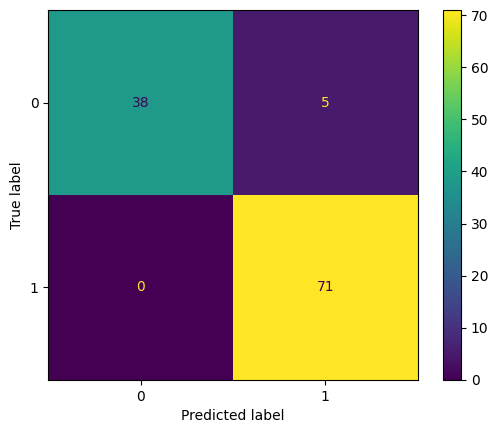

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

data = load_breast_cancer(as_frame=True)

df = data.frame

df.head()

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = KNeighborsClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()


**Using Standard Scaling**

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 1. Learn mean and std from training data, then scale training data
X_train_scaled = scaler.fit_transform(X_train)

# 2. Scale test data using the *same* mean and std learned from training data
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)
y_pred_scaled = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_scaled)
precision = precision_score(y_test, y_pred_scaled)
recall = recall_score(y_test, y_pred_scaled)
f1 = f1_score(y_test, y_pred_scaled)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

Accuracy : 0.947
Precision: 0.958
Recall   : 0.958
F1 Score : 0.958


# ⚖️ Feature Scaling: The Problem & Solution with `StandardScaler`

---

## 1. 🚨 The Problem: Feature Dominance

In distance-based algorithms like **K-Nearest Neighbors (KNN)**, **Support Vector Machines (SVM)**, and **K-Means Clustering**, prediction accuracy relies on calculating geometric distances (e.g., Euclidean distance) between data points.

When features exist on vastly different numeric scales, **features with larger magnitude completely dominate distance calculations**, rendering smaller-scale features effectively invisible to the algorithm.

### 📐 Mathematical Breakdown of the Problem

Consider two features used to predict health risk:
* **Age:** Ranges from `18` to `80` (Difference $\Delta \approx 62$)
* **Income:** Ranges from `$20,000` to `$200,000` (Difference $\Delta \approx 180,000$)

When calculating Euclidean distance between two data points $p$ and $q$:

$$d(p, q) = \sqrt{(\text{Age}_2 - \text{Age}_1)^2 + (\text{Income}_2 - \text{Income}_1)^2}$$

* A maximum difference in **Age** contributes: $(80 - 18)^2 = 3,844$
* A modest difference in **Income** contributes: $(50,000 - 20,000)^2 = 900,000,000$

Because $900,000,000 \gg 3,844$, **the model classifies points almost exclusively based on Income**, ignoring Age entirely—even if Age is actually the more predictive feature.

---

## 2. 🛠️ How `StandardScaler` Solves It (Standardization)

`StandardScaler` solves this problem by performing **Z-score Normalization** (Standardization). It transforms each feature column independently so that the transformed dataset has:
1. **Mean ($\mu$) = 0**
2. **Standard Deviation ($\sigma$) = 1**

### 🧮 The Standardization Formula

For every feature value $x$, `StandardScaler` calculates a scaled score $z$:

$$z = \frac{x - \mu}{\sigma}$$

Where:
* $x$ = Original value of the feature
* $\mu$ = Mean of the feature column ($\mu = \frac{1}{N}\sum x_i$)
* $\sigma$ = Standard deviation of the feature column ($\sigma = \sqrt{\frac{1}{N}\sum (x_i - \mu)^2}$)

### 🔄 The Result
* **Equal Weighting:** All features are mapped to a shared unit scale (typically ranging between $-3$ and $+3$). A $1$-unit change in Age now carries equal weight to a $1$-unit change in Income.
* **Shape Preservation:** It rescales the distribution without changing the relative distances between points within that feature column.

---

## 💻 Best Practice Implementation (`scikit-learn`)

To prevent **data leakage** (accidentally exposing test data properties to the model during training), calculate $\mu$ and $\sigma$ *only* on the training set:

```python
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# 1. Fit & transform training set (computes mu & sigma from X_train)
X_train_scaled = scaler.fit_transform(X_train)

# 2. Transform test set (uses the EXACT mu & sigma learned from X_train)
X_test_scaled = scaler.transform(X_test)

**Expiriment**

In [11]:
for k in [1, 3, 5, 7, 9, 11, 13, 15, 20]:
    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    print(f"K-Neighbors {k}: {accuracy:.3f}")

K-Neighbors 1: 0.930
K-Neighbors 3: 0.930
K-Neighbors 5: 0.956
K-Neighbors 7: 0.956
K-Neighbors 9: 0.956
K-Neighbors 11: 0.982
K-Neighbors 13: 0.974
K-Neighbors 15: 0.965
K-Neighbors 20: 0.965
